## Вариант 8

In [1]:
import helpers
import numpy as np
import sympy as sp 
import matplotlib.pyplot as plt
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')
x = sp.Symbol('x', real=True)

## Задание 2.3. Решение СЛАУ методом Крамера

**Цель:** Найти решение системы линейных алгебраических уравнений $Ax = b$, где $A$ — матрица коэффициентов, $b$ — вектор свободных членов.

**Теория:** Согласно методу Крамера, если определитель матрицы $\Delta = \det(A) \neq 0$, то система имеет единственное решение, определяемое формулами:
$$x_i = \frac{\Delta_i}{\Delta}$$
где $\Delta_i$ — определитель матрицы, полученной из $A$ заменой $i$-го столбца вектором $b$.

In [6]:
# 1. Определение данных
A_mat = sp.Matrix([
    [0.040, 0.032, 0.500, 0.350], 
    [-0.020, 0.200, 0.053, 0.200], 
    [0.850, 0.267, 0.089, 0.208], 
    [0.023, 0.450, -0.067, 0.200]
])
b_vec = sp.Matrix([2.481, 1.182, 8.520, 2.205])

# 2. Пошаговый вывод текста и формул
display(Math(r"\text{Задание 2.3. Решение СЛАУ методом Крамера:}"))

display(Math(r"\text{1. Запишем исходную систему в матричном виде } Ax = b:"))
display(Math(rf"A = {sp.latex(A_mat)}, \quad b = {sp.latex(b_vec)}"))

# Вычисляем главный определитель
delta = A_mat.det()
display(Math(r"\text{2. Вычислим главный определитель матрицы } A:"))
display(Math(rf"\Delta = \det(A) = {delta:.6f}"))

display(Math(r"\text{3. Пошагово вычислим вспомогательные определители } \Delta_i \text{ и корни } x_i = \Delta_i / \Delta:"))

solutions = []
for i in range(A_mat.shape[1]):
    Ai = A_mat.copy()
    # Заменяем i-й столбец вектором b
    Ai[:, i] = b_vec 
    
    d_i = Ai.det()
    xi = d_i / delta
    solutions.append(xi)
    
    # Выводим каждый корень отдельной строкой. 
    # Используем {{ }} для LaTeX индексов, чтобы Python f-строка не ломалась
    display(Math(rf"\Delta_{{{i+1}}} = {d_i:.6f} \implies x_{{{i+1}}} = {xi:.3f}"))

display(Math(r"\text{4. Итоговый вектор решения системы:}"))
# Выводим вектор, округлив значения до 3 знаков для аккуратности
final_sol = sp.Matrix(solutions).T
display(Math(rf"x = {sp.latex(final_sol.evalf(4))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Задание 3.8. Исследование асимптот функции

**Функция:** $f(x) = \frac{x^3 + x^2 - 3x - 1}{x^2 - 1}$

**Алгоритм:**
1. **Вертикальные асимптоты:** Находятся в точках разрыва (где знаменатель равен нулю).
2. **Наклонные асимптоты ($y = kx + b$):**
   $$k = \lim_{x \to \infty} \frac{f(x)}{x}, \quad b = \lim_{x \to \infty} (f(x) - kx)$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

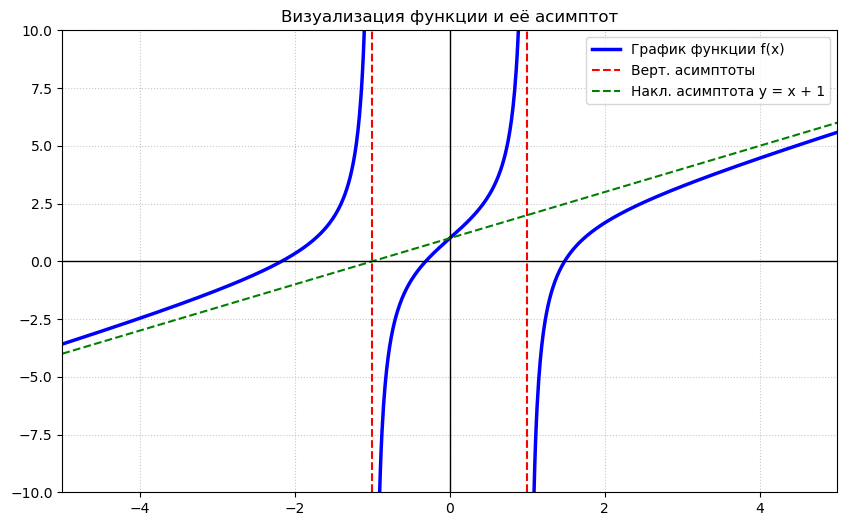

In [17]:
# 1. Аналитические вычисления
x = sp.Symbol('x', real=True)
f8 = (x**3 + x**2 - 3*x - 1) / (x**2 - 1)

# 1.1 Вертикальные асимптоты
v_as = sp.solve(x**2 - 1, x)

# 1.2 Наклонная асимптота y = kx + b
k = sp.limit(f8 / x, x, sp.oo)
b_val = sp.limit(f8 - k*x, x, sp.oo)
slant_eq = k*x + b_val

# 2. Вывод текста и формул по шагам (каждый display — это новый абзац)
display(Math(r"\text{Задание 3.8. Исследование асимптот функции:}"))

display(Math(rf"f(x) = {sp.latex(f8)}"))

display(Math(r"\text{1. Нахождение вертикальных асимптот (нули знаменателя):}"))

display(Math(rf"x^2 - 1 = 0 \implies x_1 = -1, \quad x_2 = 1"))

display(Math(r"\text{2. Нахождение наклонной асимптоты } y = kx + b \text{ с помощью пределов:}"))

# Вычисляем k
display(Math(rf"k = \lim_{{x \to \infty}} \frac{{f(x)}}{{x}} = {k}"))

# Вычисляем b
display(Math(rf"b = \lim_{{x \to \infty}} (f(x) - kx) = {b_val}"))

display(Math(rf"\text{{Уравнение наклонной асимптоты: }} y = {sp.latex(slant_eq)}"))

# 3. Графическая часть
f_num = sp.lambdify(x, f8, 'numpy')
s_num = sp.lambdify(x, slant_eq, 'numpy')

x_vals = np.linspace(-5, 5, 1000)
y_vals = f_num(x_vals)

# Очистка графика от вертикальных линий-склеек в точках разрыва
y_vals[np.abs(y_vals) > 25] = np.nan 

plt.figure(figsize=(10, 6))

# Рисуем саму функцию
plt.plot(x_vals, y_vals, label='График функции f(x)', color='blue', lw=2.5)

# Рисуем вертикальные асимптоты
for i, va in enumerate(v_as):
    label = 'Верт. асимптоты' if i == 0 else ""
    plt.axvline(x=float(va), color='red', linestyle='--', lw=1.5, label=label)

# Рисуем наклонную асимптоту
plt.plot(x_vals, s_num(x_vals), color='green', linestyle='--', lw=1.5, label=f'Накл. асимптота y = {sp.latex(slant_eq)}')

# Настройка осей, сетки и лимитов
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.ylim(-10, 10)
plt.xlim(-5, 5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.title("Визуализация функции и её асимптот")

plt.show()

## Задание 3.9. Построение графика и поиск корней

**Функция:** $f(x) = 1 - \sqrt[3]{(x-2)^2 - 1}$

Находим точки пересечения с осями координат:
- С осью $OX$: решаем уравнение $f(x) = 0$.
- С осью $OY$: вычисляем $f(0)$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

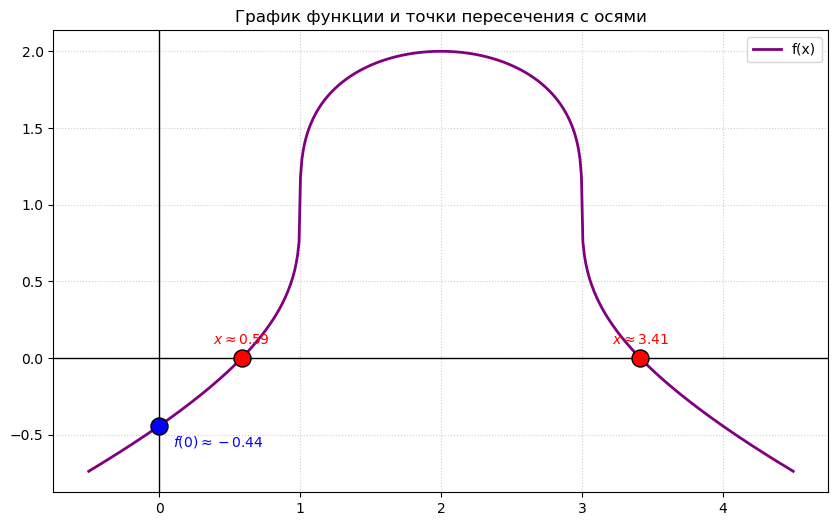

In [16]:
# 1. Аналитические вычисления
x = sp.Symbol('x', real=True)
f39 = 1 - ((x - 2)**2 - 1)**sp.Rational(1, 3)

# Находим корни
roots_ox = sp.solve(f39, x)
y_int = f39.subs(x, 0)

# 2. Вывод текста (используем удвоенные скобки {{ }} там, где это текст LaTeX)
display(Math(r"\text{Задание 3.9. Построение графика и поиск корней:}"))

display(Math(rf"f(x) = {sp.latex(f39)}"))

display(Math(r"\text{1. Нахождение точек пересечения с осью } OX \text{ (корни уравнения } f(x) = 0\text{):}"))

display(Math(rf"x_1 = {sp.latex(roots_ox[0])}, \quad x_2 = {sp.latex(roots_ox[1])}"))

# Чтобы не было ошибки SyntaxError, мы используем конструкцию {{ }} для \text
display(Math(rf"\text{{Приближенные значения: }} x_1 \approx {float(roots_ox[0]):.3f}, \quad x_2 \approx {float(roots_ox[1]):.3f}"))

display(Math(r"\text{2. Нахождение точки пересечения с осью } OY \text{ (вычисление } f(0)\text{):}"))

display(Math(rf"f(0) = 1 - \sqrt[3]{{3}} \approx {y_int.evalf():.3f}"))

# 3. Графическая часть
def real_cbrt(val):
    return np.sign(val) * np.abs(val)**(1/3)

f_lambda = lambda xv: 1 - real_cbrt((xv - 2)**2 - 1)

x_plt = np.linspace(-0.5, 4.5, 500)
y_plt = [f_lambda(val) for val in x_plt]

plt.figure(figsize=(10, 6))
plt.plot(x_plt, y_plt, label='f(x)', color='purple', lw=2)

# Отмечаем корни
for root in roots_ox:
    rx = float(root)
    plt.scatter(rx, 0, color='red', s=150, zorder=5, edgecolors='black')
    plt.annotate(rf'$x \approx {rx:.2f}$', (rx, 0), textcoords="offset points", 
                 xytext=(0,10), ha='center', color='red', weight='bold')

# Отмечаем пересечение с OY
ry = float(y_int)
plt.scatter(0, ry, color='blue', s=150, zorder=5, edgecolors='black')
plt.annotate(rf'$f(0) \approx {ry:.2f}$', (0, ry), textcoords="offset points", 
             xytext=(10,-15), color='blue', weight='bold')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("График функции и точки пересечения с осями")
plt.show()

## Задание 3.10. Исследование функции с помощью первой производной

**Функция:** $f(x) = (x+4)e^{-x-3}$

Ищем критические точки ($f'(x) = 0$) и определяем локальные экстремумы.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

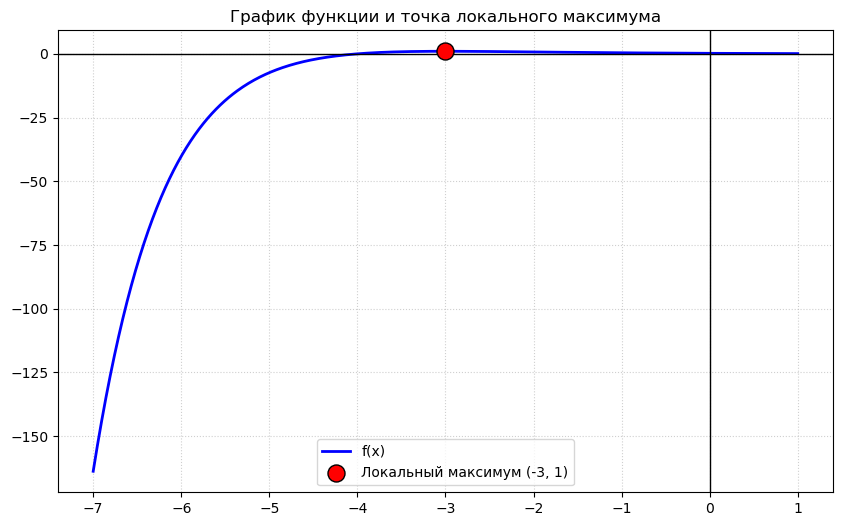

In [12]:
# 1. Аналитические вычисления
# Объявляем x как вещественное для красивого вывода
x = sp.Symbol('x', real=True)
f10 = (x + 4) * sp.exp(-x - 3)

# Находим производную
df10 = sp.diff(f10, x).simplify()

# 2. Вывод текста и формул по шагам (каждый display — это новый абзац)
display(Math(r"\text{Исследование функции с помощью первой производной:}"))

display(Math(rf"f(x) = {sp.latex(f10)}"))

display(Math(r"\text{1. Найдем первую производную функции:}"))

display(Math(rf"f'(x) = {sp.latex(df10)}"))

display(Math(r"\text{2. Нахождение экстремума:}"))

display(Math(r"\text{Решим уравнение } f'(x) = 0. \text{ Критическая точка: } x = -3."))

display(Math(r"\text{В данной точке функция достигает своего локального максимума.}"))

# 3. Построение графика
f10_func = sp.lambdify(x, f10, "numpy")
x_range = np.linspace(-7, 1, 500)
y_vals = f10_func(x_range)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_vals, color='blue', label='f(x)', lw=2)

# Отмечаем точку максимума (-3, 1)
plt.scatter(-3, 1, color='red', s=150, zorder=5, edgecolors='black', label='Локальный максимум (-3, 1)')

# Оформление
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("График функции и точка локального максимума")
plt.show()

## Задание 3.11. Исследование выпуклости и точек перегиба

**Функция:** $f(x) = \sqrt[3]{(x-4)^2(x+2)}$

Точки перегиба ищем там, где $f''(x) = 0$ или не существует.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

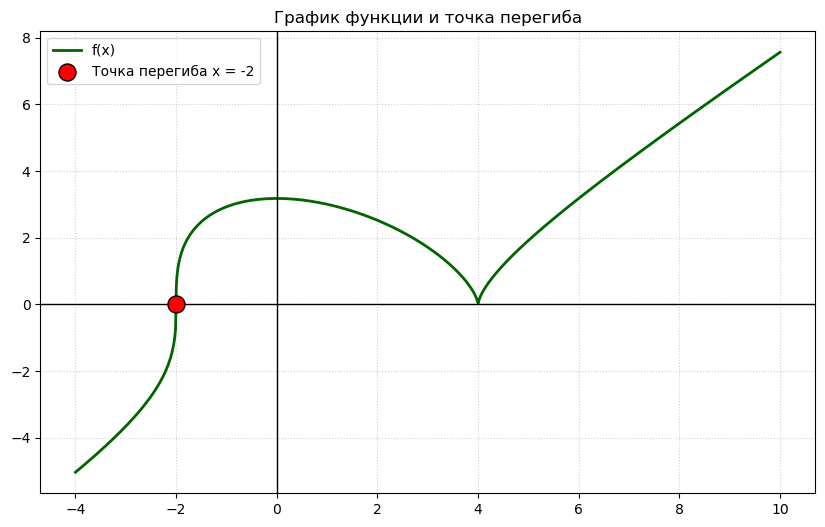

In [8]:
# 1. Обязательно объявляем x как вещественное, чтобы производная была чистой
x = sp.Symbol('x', real=True)
f11 = ((x - 4)**2 * (x + 2))**sp.Rational(1, 3)

# Находим производную и ПРИНУДИТЕЛЬНО упрощаем её
d2f11 = sp.diff(f11, x, 2).simplify()

# 2. Вывод по строкам (каждый display - это новый абзац в PDF)
display(Math(r"\text{Аналитические вычисления:}"))

display(Math(rf"f(x) = {sp.latex(f11)}"))

display(Math(rf"f''(x) = {sp.latex(d2f11)}"))

display(Math(r"\text{Точки перегиба ищем там, где } f''(x) = 0 \text{ или не существует.}"))

display(Math(r"\text{Для данной функции точка перегиба: } x = -2."))

# 3. График (бронебойный вариант)
def real_cbrt(val): 
    return np.sign(val) * np.abs(val)**(1/3)

f11_func = lambda xv: real_cbrt((xv - 4)**2 * (xv + 2))
x_vals = np.linspace(-4, 10, 1000)
y_vals = [f11_func(v) for v in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='darkgreen', label='f(x)', lw=2)

# Ставим точку перегиба
plt.scatter(-2, 0, color='red', s=150, zorder=5, edgecolors='black', label='Точка перегиба x = -2')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("График функции и точка перегиба")
plt.show()